In [ ]:
import pandas as pd
import sqlite3

df = pd.read_csv('/CLEAN_DATA.csv')
conn = sqlite3.connect(':memory:')
df.to_sql('health_data', conn, index=False, if_exists='replace')

print('Loaded! Rows:', len(df))

Loaded! Rows: 111


In [ ]:
query = "SELECT * FROM health_data LIMIT 10;"
pd.read_sql_query(query, conn)

,State_UT,Area,Glucose_Women_Pct,Glucose_Men_Pct,BP_Women_Pct,BP_Men_Pct,Overweight_Women_Pct,Overweight_Men_Pct,Data_Quality_Flag
0,India,Urban,16.27,17.85,23.62,26.61,33.24,29.79,OK
1,India,Rural,12.27,14.51,20.21,22.73,19.68,19.33,OK
2,India,Total,13.51,15.58,21.28,23.98,24.02,22.88,OK
3,Andaman & Nicobar Islands,Urban,19.64,19.44,23.43,28.17,41.72,37.04,OK
4,Andaman & Nicobar Islands,Rural,16.19,17.12,26.40,31.24,35.71,50.58,OK
5,Andaman & Nicobar Islands,Total,17.47,17.93,25.29,30.16,38.11,45.30,OK
6,Andhra Pradesh,Urban,23.24,24.88,27.54,32.16,44.37,37.74,OK
7,Andhra Pradesh,Rural,17.90,20.49,24.28,27.64,32.57,27.99,OK
8,Andhra Pradesh,Total,19.50,21.81,25.26,29.00,36.25,31.08,OK
9,Arunachal Pradesh,Urban,9.56,12.03,25.31,33.19,28.91,32.44,OK


In [ ]:
query = """
SELECT ROUND(AVG(Glucose_Women_Pct), 2) AS national_avg_glucose_women
FROM health_data
WHERE Area = 'Total' AND State_UT != 'India';
"""
pd.read_sql_query(query, conn)

,national_avg_glucose_women
0,13.86


In [ ]:
query = """
SELECT State_UT, BP_Men_Pct
FROM health_data
WHERE Area = 'Total' AND State_UT != 'India'
ORDER BY BP_Men_Pct DESC
LIMIT 10;
"""
pd.read_sql_query(query, conn)

,State_UT,BP_Men_Pct
0,Sikkim,41.58
1,Punjab,37.73
2,Manipur,33.19
3,Arunachal Pradesh,33.07
4,Kerala,32.76
5,NCT of Delhi,32.75
6,Uttarakhand,31.80
7,Telangana,31.39
8,Chandigarh,30.62
9,Andaman & Nicobar Islands,30.16


In [ ]:
query = """
SELECT State_UT, Overweight_Women_Pct
FROM health_data
WHERE Area = 'Total' AND State_UT != 'India'
AND Overweight_Women_Pct > (
    SELECT AVG(Overweight_Women_Pct)
    FROM health_data
    WHERE Area = 'Total' AND State_UT != 'India'
)
ORDER BY Overweight_Women_Pct DESC;
"""
pd.read_sql_query(query, conn)

,State_UT,Overweight_Women_Pct
0,Puducherry,46.20
1,Chandigarh,44.02
2,NCT of Delhi,41.32
3,Punjab,40.81
4,Tamil Nadu,40.44
5,Kerala,38.12
6,Andaman & Nicobar Islands,38.11
7,Andhra Pradesh,36.25
8,Goa,36.09
9,Sikkim,34.71


In [ ]:
query = """
SELECT State_UT, Area, Glucose_Women_Pct, BP_Women_Pct, Overweight_Women_Pct
FROM health_data
WHERE State_UT = 'Kerala';
"""
pd.read_sql_query(query, conn)

,State_UT,Area,Glucose_Women_Pct,BP_Women_Pct,Overweight_Women_Pct
0,Kerala,Urban,24.83,30.74,40.41
1,Kerala,Rural,24.81,31.01,36.03
2,Kerala,Total,24.82,30.88,38.12


In [ ]:
query = """
SELECT State_UT, BP_Men_Pct,
CASE
    WHEN BP_Men_Pct >= 30 THEN 'Higher reported level'
    WHEN BP_Men_Pct >= 20 THEN 'Moderate reported level'
    ELSE 'Lower reported level'
END AS BP_Category
FROM health_data
WHERE Area = 'Total' AND State_UT != 'India'
ORDER BY BP_Men_Pct DESC;
"""
pd.read_sql_query(query, conn)

,State_UT,BP_Men_Pct,BP_Category
0,Sikkim,41.58,Higher reported level
1,Punjab,37.73,Higher reported level
2,Manipur,33.19,Higher reported level
3,Arunachal Pradesh,33.07,Higher reported level
4,Kerala,32.76,Higher reported level
5,NCT of Delhi,32.75,Higher reported level
6,Uttarakhand,31.80,Higher reported level
7,Telangana,31.39,Higher reported level
8,Chandigarh,30.62,Higher reported level
9,Andaman & Nicobar Islands,30.16,Higher reported level


In [ ]:
import pandas as pd

df = pd.read_csv('/CLEAN_DATA.csv')

df.head()

,State_UT,Area,Glucose_Women_Pct,Glucose_Men_Pct,BP_Women_Pct,BP_Men_Pct,Overweight_Women_Pct,Overweight_Men_Pct,Data_Quality_Flag
0,India,Urban,16.27,17.85,23.62,26.61,33.24,29.79,OK
1,India,Rural,12.27,14.51,20.21,22.73,19.68,19.33,OK
2,India,Total,13.51,15.58,21.28,23.98,24.02,22.88,OK
3,Andaman & Nicobar Islands,Urban,19.64,19.44,23.43,28.17,41.72,37.04,OK
4,Andaman & Nicobar Islands,Rural,16.19,17.12,26.40,31.24,35.71,50.58,OK


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State_UT              111 non-null    object 
 1   Area                  111 non-null    object 
 2   Glucose_Women_Pct     111 non-null    float64
 3   Glucose_Men_Pct       111 non-null    float64
 4   BP_Women_Pct          111 non-null    float64
 5   BP_Men_Pct            111 non-null    float64
 6   Overweight_Women_Pct  110 non-null    float64
 7   Overweight_Men_Pct    110 non-null    float64
 8   Data_Quality_Flag     111 non-null    object 
dtypes: float64(6), object(3)
memory usage: 7.9+ KB


In [ ]:
df.isna().sum()

,0
State_UT,0
Area,0
Glucose_Women_Pct,0
Glucose_Men_Pct,0
BP_Women_Pct,0
BP_Men_Pct,0
Overweight_Women_Pct,1
Overweight_Men_Pct,1
Data_Quality_Flag,0


In [ ]:
df.describe()

,Glucose_Women_Pct,Glucose_Men_Pct,BP_Women_Pct,BP_Men_Pct,Overweight_Women_Pct,Overweight_Men_Pct
count,111.000000,111.000000,111.000000,111.000000,110.000000,110.000000
mean,14.116306,16.111351,22.601622,26.425315,28.502727,28.297636
std,4.427543,4.463899,4.544621,6.061935,10.002686,9.269643
min,6.420000,5.400000,13.480000,13.850000,8.610000,10.600000
25%,10.720000,13.360000,19.965000,21.455000,20.770000,21.347500
50%,13.600000,15.700000,22.500000,25.980000,29.285000,28.590000
75%,17.430000,18.415000,24.970000,30.525000,36.210000,34.995000
max,24.830000,27.410000,35.800000,43.060000,47.620000,50.580000


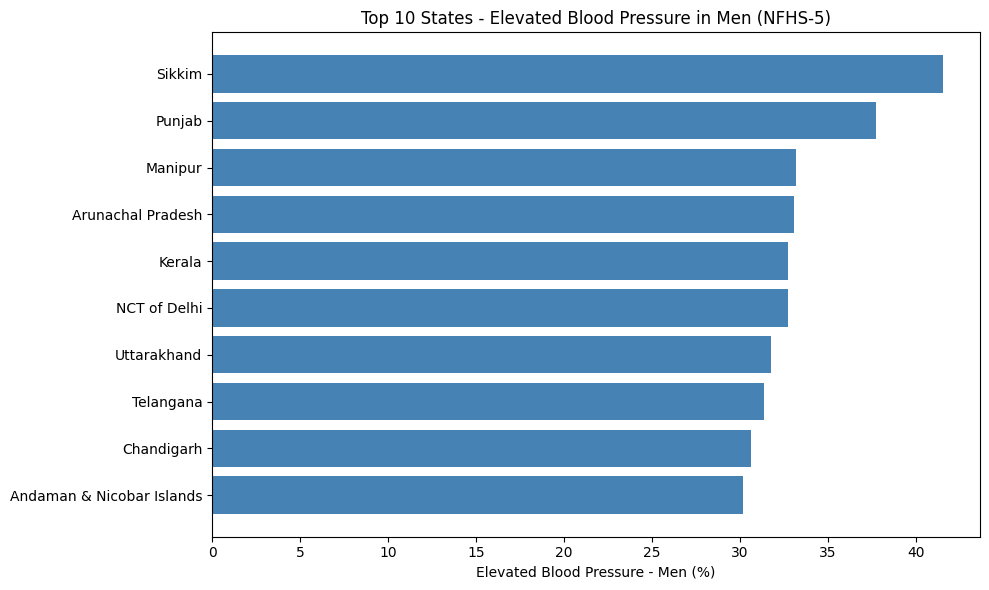

In [ ]:
import matplotlib.pyplot as plt

state_data = df[(df['Area'] == 'Total') & (df['State_UT'] != 'India')]

top10 = state_data.sort_values('BP_Men_Pct', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['State_UT'], top10['BP_Men_Pct'], color='steelblue')
plt.xlabel('Elevated Blood Pressure - Men (%)')
plt.title('Top 10 States - Elevated Blood Pressure in Men (NFHS-5)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This chart shows the 10 states/UTs with the highest reported elevated blood pressure among men (age 15+), based on NFHS-5 (2019–2021) survey data. Elevated blood pressure includes both people who tested high and those already taking medicine to control it.

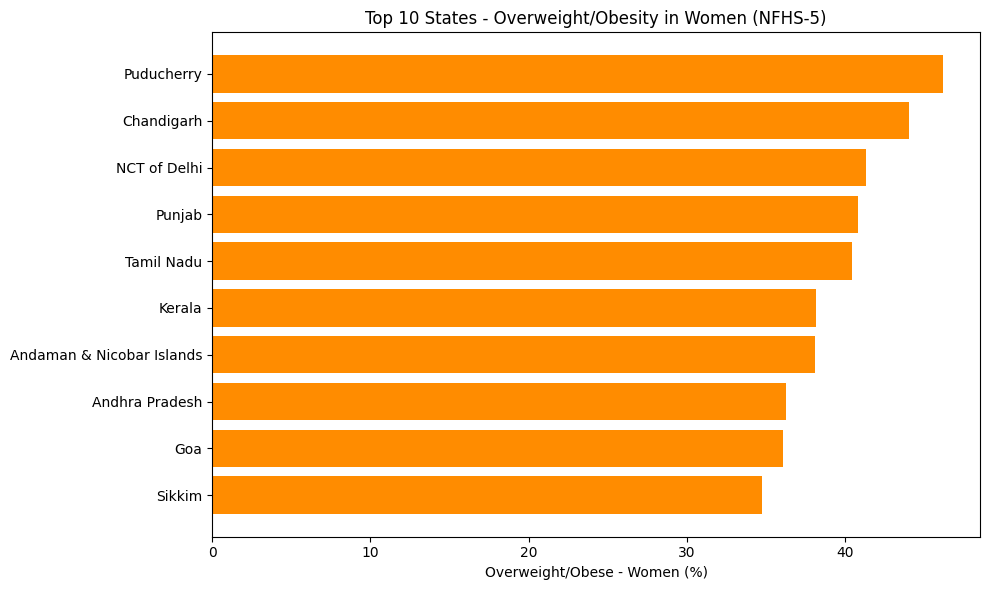

In [ ]:
top10_ow = state_data.sort_values('Overweight_Women_Pct', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10_ow['State_UT'], top10_ow['Overweight_Women_Pct'], color='darkorange')
plt.xlabel('Overweight/Obese - Women (%)')
plt.title('Top 10 States - Overweight/Obesity in Women (NFHS-5)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This chart shows the 10 states/UTs with the highest reported overweight or obesity levels among women (age 15–49), based on BMI measurements from the NFHS-5 (2019–2021) survey.

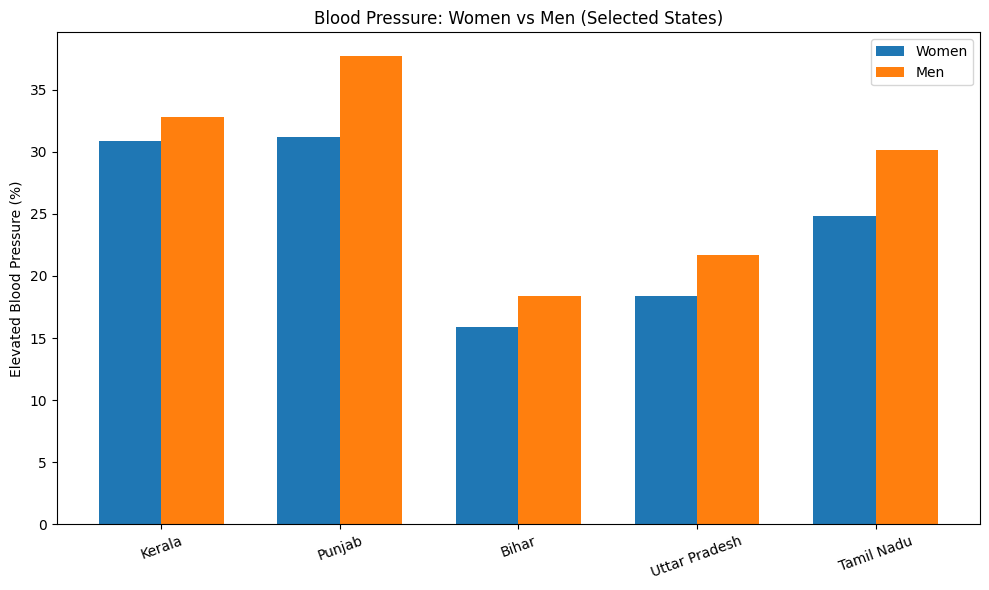

In [ ]:
import numpy as np

sample_states = ['Kerala', 'Punjab', 'Bihar', 'Uttar Pradesh', 'Tamil Nadu']
sample = state_data[state_data['State_UT'].isin(sample_states)]

x = np.arange(len(sample_states))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, sample.set_index('State_UT').loc[sample_states, 'BP_Women_Pct'], width, label='Women')
plt.bar(x + width/2, sample.set_index('State_UT').loc[sample_states, 'BP_Men_Pct'], width, label='Men')
plt.xticks(x, sample_states, rotation=20)
plt.ylabel('Elevated Blood Pressure (%)')
plt.title('Blood Pressure: Women vs Men (Selected States)')
plt.legend()
plt.tight_layout()
plt.show()

This chart compares elevated blood pressure levels between women and men across five selected states, showing that men consistently report higher rates than women in each of these states within this dataset.

**Summary of Findings**

This analysis of NFHS-5 (2019–2021) data across 36 Indian states and union territories reveals meaningful variation in lifestyle-disease indicators. Kerala reports the highest levels of high blood sugar for both women and men, despite often being cited as one of India's better-performing states on other health metrics — this may reflect stronger testing and healthcare access rather than worse underlying health. Sikkim shows the highest reported elevated blood pressure for both sexes, and Meghalaya reports the highest overweight/obesity levels.

Across almost every indicator, men report higher percentages than women, and there is wide variation between states — for example, blood pressure in men ranges from roughly 14% to 43% depending on the state.

Important limitation: this data describes population-level patterns from a survey, not individual medical records. It cannot explain why these differences exist, and higher reported levels in a state should not be read as that state being "unhealthier" — testing rates, healthcare access, urbanization, and reporting practices all likely play a role.